In [1]:
import os
from datetime import datetime
from typing import Dict, Union
import pickle
import pandas as pd
import torch
from azureml.core import Workspace, Dataset, Datastore

In [2]:
EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/ARF.csv"
MAPPING_PATH = "Zahra/022026/Data/PreMEDS_MDPS/hash_to_integer_map.pkl"
DATASTORE_NAME = "researcher_data"

# Azure ML workspace configuration
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

TIMESTAMP_COL = 'time'
ABSPOS_COL = 'abspos'
PID_COL = 'subject_id'
MANDATORY_COLUMNS = [TIMESTAMP_COL, PID_COL]


In [3]:
def get_workspace() -> Workspace:
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

# -------------------
# Load CSV from Datastore
# -------------------
def read_csv_from_datastore(
    ws: Workspace,
    datastore_name: str,
    csv_path: str,
    rename_dict: Dict[str, str] = None,
    local_dir: str = "./temp_data"
) -> pd.DataFrame:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, csv_path))
    file_paths = dataset.download(target_path=local_dir, overwrite=True)
    df = pd.read_csv(file_paths[0])
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df


# -------------------
# Load PyTorch Mapping File from Datastore
# -------------------

def load_mapping_from_datastore_file(
    ws: Workspace,
    datastore_name: str,
    file_path: str,
    local_dir: str = "./temp_data"
) -> Dict[str, int]:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, file_path))
    downloaded_files = dataset.download(target_path=local_dir, overwrite=True)
    
    local_path = downloaded_files[0]
            
    with open(local_path, "rb") as f:
        mapping = pickle.load(f)
    
    return mapping
# -------------------
# Data Cleaning Utilities
# -------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    if all(col in df.columns for col in MANDATORY_COLUMNS):
        df = df.dropna(subset=MANDATORY_COLUMNS, how="any")
    df = df.drop_duplicates()
    return df


def get_hours_since_epoch(timestamps: Union[pd.Series, datetime]) -> Union[pd.Series, float]:
    if isinstance(timestamps, pd.Series):
        if len(timestamps) == 0:
            return pd.Series([], dtype=float)
        timestamps = pd.to_datetime(timestamps, utc=True, errors="coerce").dt.tz_localize(None)
        seconds = timestamps.view("int64") // 10**9  # ✅ بدون اخطار در پانداس جدید
        hours = seconds / 3600
        return hours
    else:
        ts = pd.to_datetime(timestamps, utc=True).tz_localize(None)
        return (ts.value // 10**9) / 3600

def map_pids_to_ints(df: pd.DataFrame, pid_map: Dict[str, int]) -> pd.DataFrame:
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df = df.copy()
    #df.loc[:, PID_COL] = df[PID_COL].astype(int)
    df[PID_COL] = df[PID_COL].astype(int)
    return df


In [4]:
if __name__ == "__main__":
    ws = get_workspace()

# -------------------
# Reading Data
# -------------------
    exposure = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=EXPOSURE_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )

    outcome = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=OUTCOME_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
# -------------------
# Clean Data
# -------------------
    exposure = clean_data(exposure)
    outcome = clean_data(outcome)

    print(" Raw exposure TIMESTAMP samples:")
    print(exposure.head(10))
    print(exposure.dtypes)

    print("\n Raw outcome TIMESTAMP samples:")
    print(outcome[TIMESTAMP_COL].head(10))
    print(outcome.dtypes)
# -------------------
# Load Mapping file
# -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )
# -------------------
# Map pids to ints
# -------------------
    exposure = map_pids_to_ints(exposure, pid_map)
    outcome = map_pids_to_ints(outcome, pid_map)
# -------------------
# Change Abspos col
# -------------------
    exposure[ABSPOS_COL] = get_hours_since_epoch(exposure[TIMESTAMP_COL]).astype(int)
    outcome[ABSPOS_COL] = get_hours_since_epoch(outcome[TIMESTAMP_COL]).astype(int)

    print("Exposure sample:")
    print(exposure.head())

    print("Outcome ARF sample:")
    print(outcome.head())

Timeout was exceeded in force_flush().
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
 Raw exposure TIMESTAMP samples:
                                          subject_id        time  abspos
0  88572797278B2604219A1962B005B801289909140F1CA7...  2016-05-24  -32208
1  A34E5948E6C23BDED4FCD553D0BC34649EE22759D15454...  2016-06-22  -31512
2  E8B62CFB71809D901D1F101BFE66F5EB2DD1718227E698...  2016-11-05  -28248
3  F3046580D734B72A9297A8D2F78D0C32DEFB51ED1B71E0...  2016-11-05  -28248
4  E11AAAD876434636E91090720629285F45E1F3988CA7AB...  2016-11-07  -28200
5  B8D182E9A64ABD5B53218D83FB5

In [5]:
import pandas as pd

# Assume: df_exposure and df_outcome are already read from files
# df_exposure = pd.read_csv("exposure.csv")
# df_outcome = pd.read_csv("outcome.csv")

# Convert time columns to datetime
exposure["time"] = pd.to_datetime(exposure["time"])
outcome["time"] = pd.to_datetime(outcome["time"])

# Get the earliest exposure time for each subject
exposure_min = exposure.groupby("subject_id")["time"].min().reset_index()
exposure_min = exposure_min.rename(columns={"time": "exposure_time"})

# Join outcomes with the earliest exposure time
merged = pd.merge(outcome, exposure_min, on="subject_id", how="inner")

# Calculate the difference in days between outcome and exposure
merged["delta_days"] = (merged["time"] - merged["exposure_time"]).dt.days

# Find subjects where any outcome happened before exposure
invalid_subjects = merged.loc[merged["delta_days"] < 0, "subject_id"].unique()

if len(invalid_subjects) == 0:
    print("All outcomes occur after exposure.")
else:
    print(f" {len(invalid_subjects)} subjects have outcomes before exposure:")
    print(invalid_subjects)


All outcomes occur after exposure.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume exposure has: subject_id, time, abspos
exp = exposure.copy()

# --- dtypes ---
exp["time"] = pd.to_datetime(exp["time"], errors="coerce")

# (optional) de-dup exact duplicates per subject/time or subject/abspos
exp = exp.drop_duplicates(subset=["subject_id", "abspos"])

Subjects with exactly 1 exposure: 372551
Subjects with >1 exposure: 153454

Distribution of n_exposures (top 10 rows):
1     372551
2     103155
3      31160
4      10901
5       4259
6       1845
7        926
8        465
9        281
10       164
Name: n_exposures, dtype: int64


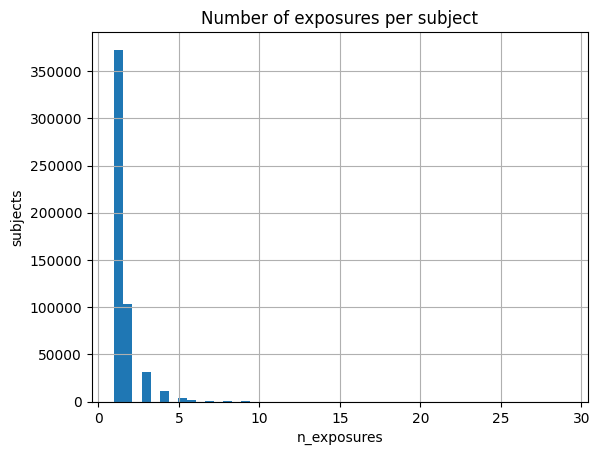

In [7]:
# =========================
# 1) How many exposures per subject?
# =========================
counts = exp.groupby("subject_id").size().rename("n_exposures")
print("Subjects with exactly 1 exposure:", (counts == 1).sum())
print("Subjects with >1 exposure:", (counts > 1).sum())

print("\nDistribution of n_exposures (top 10 rows):")
print(counts.value_counts().sort_index().head(10))

# Histogram of exposure counts
counts.hist(bins=50)
plt.title("Number of exposures per subject")
plt.xlabel("n_exposures")
plt.ylabel("subjects")
plt.show()


In [20]:
import pandas as pd

# exposure: subject_id, time, abspos
total_subjects = exposure["subject_id"].nunique()
total_exposures = len(exposure)

# اگر فقط اولین exposure هر بیمار رو نگه داریم:
kept_exposures = total_subjects
dropped_exposures = total_exposures - kept_exposures
pct_dropped_exposures = 100 * dropped_exposures / total_exposures

print("Total subjects:", total_subjects)
print("Total exposures:", total_exposures)
print("Dropped exposures (keep-first):", dropped_exposures)
print(f"% exposures dropped: {pct_dropped_exposures:.2f}%")


Total subjects: 526005
Total exposures: 766764
Dropped exposures (keep-first): 240759
% exposures dropped: 31.40%


In [8]:
exposure.to_csv("./temp_data/exposure_ARF_MDP.csv", index=False)
outcome.to_csv("./temp_data/outcome_ARF_MDP.csv", index=False)

In [9]:
task_name = "ARF Prediction"

n_exp = len(exposure)
n_exp_pat = exposure[PID_COL].nunique()

n_out = len(outcome)
n_out_pat = outcome[PID_COL].nunique()

pos_rate = n_out_pat / n_exp_pat

print(f"Task: {task_name}")
print(f"   - Exposure: {n_exp:,} records, {n_exp_pat:,} patients")
print(f"   - Outcome:  {n_out:,} records, {n_out_pat:,} patients")
print(f"   - Positive rate: {pos_rate:.2%}")


Task: ARF Prediction
   - Exposure: 766,764 records, 526,005 patients
   - Outcome:  1,786 records, 1,711 patients
   - Positive rate: 0.33%



Gaps (hours) — describe:
count    240759.000000
mean       9526.268675
std        8780.410994
min         720.000000
10%        1368.000000
25%        2856.000000
50%        6480.000000
75%       13584.000000
90%       22680.000000
95%       28248.000000
99%       37512.000000
max       50928.000000
Name: gap_hours, dtype: float64

Gaps (days) — describe:
count    240759.000000
mean        396.927861
std         365.850458
min          30.000000
10%          57.000000
25%         119.000000
50%         270.000000
75%         566.000000
90%         945.000000
95%        1177.000000
99%        1563.000000
max        2122.000000
Name: gap_hours, dtype: float64

Zero-gap exposures: 0
Negative-gap exposures: 0


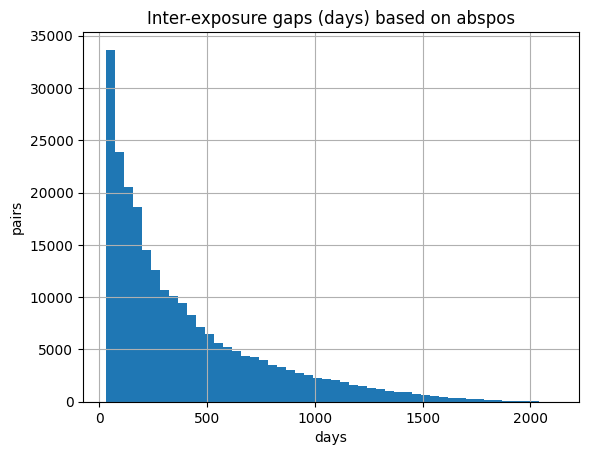

In [10]:

exp_sorted = exp.sort_values(["subject_id", "abspos"]).copy()
exp_sorted["gap_hours"] = exp_sorted.groupby("subject_id")["abspos"].diff()  # hours between consecutive exposures
gaps = exp_sorted.loc[exp_sorted["gap_hours"].notna(), "gap_hours"]

# Basic stats
print("\nGaps (hours) — describe:")
print(gaps.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))

# In days
gaps_days = gaps / 24.0
print("\nGaps (days) — describe:")
print(gaps_days.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))

# Negative/zero checks (should not happen if sorted + unique)
print("\nZero-gap exposures:", (gaps == 0).sum())
print("Negative-gap exposures:", (gaps < 0).sum())

# Histogram of gaps
gaps_days.hist(bins=50)
plt.title("Inter-exposure gaps (days) based on abspos")
plt.xlabel("days")
plt.ylabel("pairs")
plt.show()


In [11]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# تنظیمات Azure ML workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

# اتصال به workspace
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, "researcher_data")

# استخراج اطلاعات واقعی از datastore
account_name = datastore.account_name
filesystem_name = datastore.container_name
credential = DefaultAzureCredential()

def upload_to_adls2(account_name, filesystem_name, directory_path, local_file_path, remote_file_name, credential):
    service_client = DataLakeServiceClient(account_url=f"https://{account_name}.dfs.core.windows.net", credential=credential)
    file_system_client = service_client.get_file_system_client(file_system=filesystem_name)
    directory_client = file_system_client.get_directory_client(directory_path)

    print("Uploading file")

    file_client = directory_client.create_file(remote_file_name)
    with open(local_file_path, 'rb') as file_data:
        file_contents = file_data.read()
        file_client.append_data(data=file_contents, offset=0, length=len(file_contents))
        file_client.flush_data(len(file_contents))

    print(f" File Uploaded Successfully {directory_path}/{remote_file_name}")



In [12]:
directory_path = "Zahra/022026/CoreBehrt_CV/CreateOutcome/ARF"

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_ARF_MDP.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_ARF_MDP.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/022026/CoreBehrt_CV/CreateOutcome/ARF/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/022026/CoreBehrt_CV/CreateOutcome/ARF/outcome.csv


In [10]:
import pandas as pd
import numpy as np

X = 30  # days threshold

# 1) sort per subject and compute inter-exposure gaps
exp_sorted = exp.sort_values(["subject_id", "abspos"]).copy()
exp_sorted["gap_hours"] = exp_sorted.groupby("subject_id")["abspos"].diff()
exp_sorted["gap_days"]  = exp_sorted["gap_hours"] / 24.0

# (optional) keep previous exposure info for inspection
exp_sorted["prev_abspos"] = exp_sorted.groupby("subject_id")["abspos"].shift(1)
exp_sorted["exp_seq"]     = exp_sorted.groupby("subject_id").cumcount() + 1  # 1,2,3,...

# if calendar time exists, keep it too
if "time" in exp.columns:
    exp_sorted["prev_time"] = exp_sorted.groupby("subject_id")["time"].shift(1)

# 2) all consecutive-exposure pairs with gap >= X days
pairs_long = exp_sorted.loc[exp_sorted["gap_days"] >= X, 
                            ["subject_id","exp_seq","prev_abspos","abspos","gap_days"] 
                            + (["prev_time","time"] if "time" in exp.columns else [])]\
                         .rename(columns={"abspos":"abspos_curr","time":"time_curr"})

print(f"Number of long-gap pairs (≥ {X} days): {len(pairs_long)}")

# 3) unique subjects who have at least one long gap
subjects_with_long = pairs_long["subject_id"].nunique()
print(f"Unique subjects with ≥{X}d gap between exposures: {subjects_with_long}")

# 4) subjects with exactly 2 exposures whose single gap is ≥ X
counts = exp.groupby("subject_id").size()
exact2_ids = set(counts[counts == 2].index)
exact2_long = len(exact2_ids & set(pairs_long["subject_id"]))
print(f"Subjects with exactly 2 exposures and gap ≥{X}d: {exact2_long}")

# 5) (optional) subjects for whom ALL gaps are ≥ X (if they have ≥2 exposures)
min_gap_per_subj = exp_sorted.groupby("subject_id")["gap_days"].min()
all_gaps_ge_X_ids = min_gap_per_subj[min_gap_per_subj.notna() & (min_gap_per_subj >= X)].index
print(f"Subjects with ALL inter-exposure gaps ≥{X}d: {len(all_gaps_ge_X_ids)}")

# 6) preview and/or save
print("\nSample rows:")
print(pairs_long.head(10))

# pairs_long.to_csv(f"subjects_gap_ge_{X}d_pairs.csv", index=False)
# pd.Series(sorted(subjects_with_long)).to_csv(f"subjects_gap_ge_{X}d_ids.csv", index=False, header=["subject_id"])


Number of long-gap pairs (≥ 30 days): 240759
Unique subjects with ≥30d gap between exposures: 153454
Subjects with exactly 2 exposures and gap ≥30d: 103155
Subjects with ALL inter-exposure gaps ≥30d: 153454

Sample rows:
        subject_id  exp_seq  prev_abspos  abspos_curr  gap_days  prev_time  \
546305           5        2     438912.0       445320     267.0 2020-01-27   
358829          39        2     433248.0       434376      47.0 2019-06-05   
379147          39        3     434376.0       436104      72.0 2019-07-22   
379153          39        4     436104.0       442632     272.0 2019-10-02   
741960          45        2     451056.0       457056     250.0 2021-06-16   
67850           70        2     412272.0       417576     221.0 2017-01-12   
173395          70        3     417576.0       424296     280.0 2017-08-21   
409190          91        2     419688.0       437232     731.0 2017-11-17   
512420          91        3     437232.0       444624     308.0 2019-11-18   

در دیتاست تو ۲۴۰ هزار بار یک فرد بعد از ≥۳۰ روز دوباره 

exposure گرفته

یعنی اکثر مردم:


exposed → long time → exposed again → done

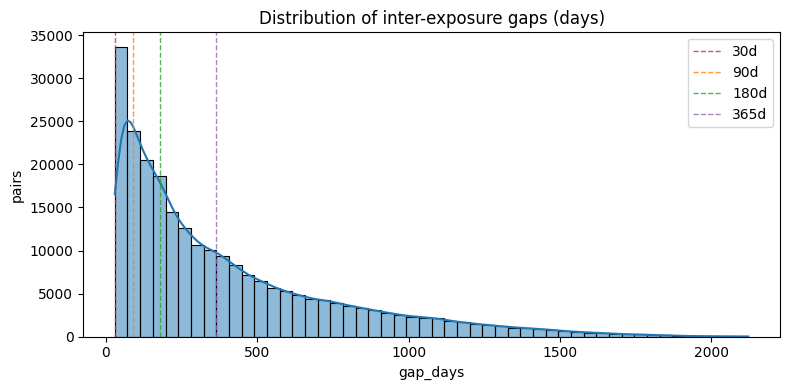

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(pairs_long["gap_days"], bins=50, kde=True, color="#1f77b4")
for d, c in [(30,"#d62728"), (90,"#ff7f0e"), (180,"#2ca02c"), (365,"#9467bd")]:
    plt.axvline(d, color=c, ls="--", lw=1, alpha=0.8, label=f"{d}d")
plt.title("Distribution of inter-exposure gaps (days)")
plt.xlabel("gap_days")
plt.ylabel("pairs")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

# فرض بر اینکه exposure و outcome از قبل لود شدن

# مرحله مهم: تبدیل time به datetime
exposure["time"] = pd.to_datetime(exposure["time"])
outcome["time"] = pd.to_datetime(outcome["time"])

# join
merged_df = pd.merge(exposure, outcome, on="subject_id", suffixes=('_exposure', '_outcome'))

# فیلتر فقط زمانی که خونریزی بعد از exposure بوده
merged_df = merged_df[merged_df['time_outcome'] > merged_df['time_exposure']]

# محاسبه فاصله زمانی
merged_df["days_to_arf"] = (merged_df["time_outcome"] - merged_df["time_exposure"]).dt.days


**time_exposure**

تاریخ در معرض بودن (مثل جراحی یا شروع درمان پرخطر)

**abspos_exposure**

موقعیت زمانی نسبی (مثلاً تعداد روز از یک مبدا مثل 1 ژانویه 2000)

**time_outcome**

تاریخ وقوع outcome (در اینجا: خونریزی)


**abspos_outcome**

موقعیت زمانی نسبی outcome


**days_to_bleed**

فاصله زمانی برحسب روز بین exposure و خونریزی





In [29]:
merged_df

,subject_id,time_exposure,abspos_exposure,time_outcome,abspos_outcome,days_to_arf
0,2016544,2016-11-05,410640,2016-12-05,411360,30
4,741296,2016-11-06,410664,2016-12-06,411384,30
10,649689,2016-06-07,407016,2016-07-07,407736,30
11,1044036,2016-12-12,411528,2017-01-11,412248,30
13,1046482,2016-11-11,410784,2016-12-11,411504,30
...,...,...,...,...,...,...
4259,1311915,2017-03-27,414048,2017-04-26,414768,30
4260,461038,2016-10-24,410352,2016-11-23,411072,30
4261,1960717,2016-11-30,411240,2016-12-30,411960,30
4262,2019823,2016-11-22,411048,2016-12-22,411768,30


In [14]:
import pandas as pd

# فرض بر اینکه merged_df داری که شامل subject_id, time_exposure, time_outcome, days_to_bleed هست

# فقط outcome هایی که در ≤ 30 روز اتفاق افتادن
within_30 = merged_df[merged_df["days_to_bleed"] <= 30]

# شمارش تعداد خونریزی برای هر بیمار (بعد از هر exposure)
bleed_counts = within_30.groupby("subject_id")["time_outcome"].nunique()

# فقط بیمارانی که بیشتر از 1 بار خونریزی داشتن
multi_bleeders = bleed_counts[bleed_counts > 1]

print("تعداد بیماران با بیش از یک خونریزی ظرف 30 روز:", len(multi_bleeders))
print(multi_bleeders.head())

# اگر بخوای جزییات رکوردهای این بیماران رو ببینی:
patients_with_multiple_bleeds = within_30[within_30["subject_id"].isin(multi_bleeders.index)]
print(patients_with_multiple_bleeds.head(20))


تعداد بیماران با بیش از یک خونریزی ظرف 30 روز: 870
subject_id
8563     2
11446    2
12372    2
15264    2
20029    2
Name: time_outcome, dtype: int64
     subject_id time_exposure  abspos_exposure time_outcome  abspos_outcome  \
10      1430985    2017-06-16           415992   2017-07-16          416712   
13      1430985    2019-08-11           434856   2019-09-10          435576   
130      275592    2016-12-06           411384   2017-01-05          412104   
133      275592    2021-11-26           454968   2021-12-26          455688   
192     2031046    2017-11-30           420000   2017-12-30          420720   
195     2031046    2018-02-14           421824   2018-03-16          422544   
259     1563942    2016-11-16           410904   2016-12-16          411624   
263     1563942    2017-02-21           413232   2017-03-23          413952   
267     1563942    2017-05-17           415272   2017-06-16          415992   
268      697669    2016-11-30           411240   2016-12-30 

بررسی توزیع زمانی:

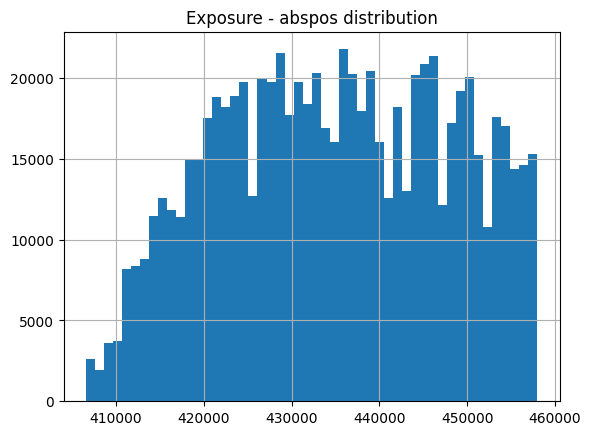

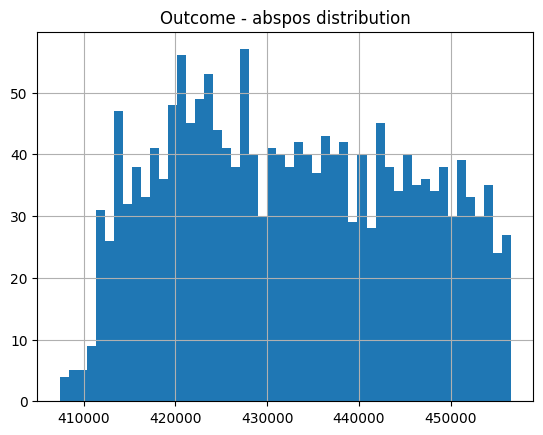

In [41]:
import matplotlib.pyplot as plt

exposure["abspos"].hist(bins=50)
plt.title("Exposure - abspos distribution")
plt.show()

outcome["abspos"].hist(bins=50)
plt.title("Outcome - abspos distribution")
plt.show()


یشتر داده‌ها در سمت چپ جمع شدن → یعنی برای بیشتر افراد، فاصله‌ی زمانی بین 

exposure و outcome 

خیلی کم بوده، مثلاً 0 تا 50 روز.

بیشترین فراوانی در بازه‌ی خیلی کوچیکه (مثلاً 0 تا 50 روز)
→ این یعنی در اکثر موارد،
 outcome خیلی سریع بعد از exposure رخ داده.

یه دُم بلند به سمت راست داریم (right skewed)

→ این یعنی بعضی افراد فاصله‌ی خیلی طولانی‌تری داشتن (مثلاً حتی تا 2000 روز = ~5.5 سال)، ولی اون‌ها تعدادشون خیلی کمه.

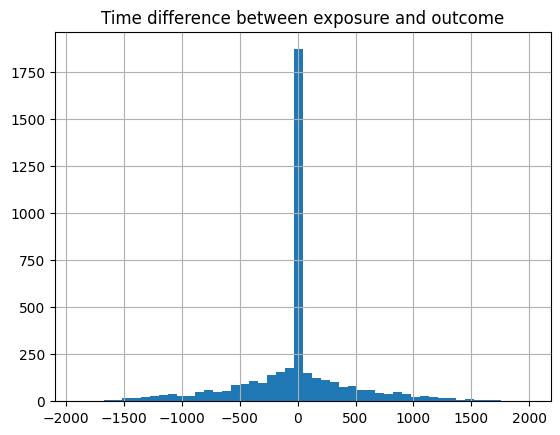

In [46]:
merged = pd.merge(exposure, outcome, on="subject_id", suffixes=("_exp", "_out"))
merged["delta_hours"] = merged["abspos_out"] - merged["abspos_exp"]
merged["delta_days"] = merged["delta_hours"] / 24
merged["delta_days"].hist(bins=50)
plt.title("Time difference between exposure and outcome")
plt.show()


بیشتر outcome

ها بلافاصله بعد از exposure

 اتفاق افتادن → احتمال وجود رابطه‌ی مستقیم یا علّی.

In [10]:
# تعداد exposure برای هر بیمار
exposure_counts = exposure["subject_id"].value_counts()

# بیمارانی که بیش از یک exposure دارن
multiple_exposures = exposure_counts[exposure_counts > 1]

print(" Total subjects:", exposure_counts.shape[0])
print(" Subjects with exactly 1 exposure:", (exposure_counts == 1).sum())
print(" Subjects with more than 1 exposure:", (exposure_counts > 1).sum())

if not multiple_exposures.empty:
    print("\nExamples of patients with multiple exposures:")
    print(multiple_exposures.head())


 Total subjects: 526005
 Subjects with exactly 1 exposure: 372551
 Subjects with more than 1 exposure: 153454

Examples of patients with multiple exposures:
312261     29
1719866    29
1541863    28
2162677    28
1281561    28
Name: subject_id, dtype: int64


In [16]:

directory_path = "Zahra/CoreBehrt/CreateOutcome/ARF"

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_ARF_MDP.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_ARF_MDP.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/ARF/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/ARF/outcome.csv
